# Employee Performance Analysis - INX Future Inc

## Certified Data Scientist (CDS) Project

### Project Objective

The objective of this project is to analyze employee performance data and identify the key factors affecting employee performance. The project also aims to build a machine learning model capable of predicting employee performance and provide recommendations to improve overall organizational performance.

# Business Understanding

INX Future Inc has observed a decline in employee performance which has affected client satisfaction and service delivery. The management wants to identify the major factors influencing employee performance and understand the root causes behind low performance. This project focuses on analyzing employee data, identifying important performance indicators and developing a predictive model that can support future hiring and employee management decisions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Libraries Used

Pandas and NumPy are used for data manipulation and analysis. Matplotlib and Seaborn are used for creating visualizations and understanding data patterns. These libraries provide the necessary tools for data preprocessing, exploratory analysis and machine learning preparation.

In [2]:
df = pd.read_excel(
    "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"
)

df.head()



,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [3]:
print("Shape :", df.shape)

df.info()

df.describe()

Shape : (1200, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13 

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


## Dataset Understanding

The dataset contains 1200 employee records and 28 features related to employee demographics, job profile, satisfaction levels, experience and performance. Both numerical and categorical variables are present in the dataset. The statistical summary and data type information were reviewed to understand the structure of the data and identify preprocessing requirements for further analysis.

In [4]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

## Feature Overview

The dataset includes employee information such as age, gender, education background, department, job role, work experience, job satisfaction, work-life balance and performance rating. These features will be analyzed to determine their impact on employee performance and support predictive modeling.

In [5]:
df['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

## Target Variable Analysis

PerformanceRating is the target variable of this project. The distribution shows that most employees belong to Performance Rating 3, while fewer employees fall under Ratings 2 and 4. This indicates a moderate class imbalance which will be considered during model development and evaluation.

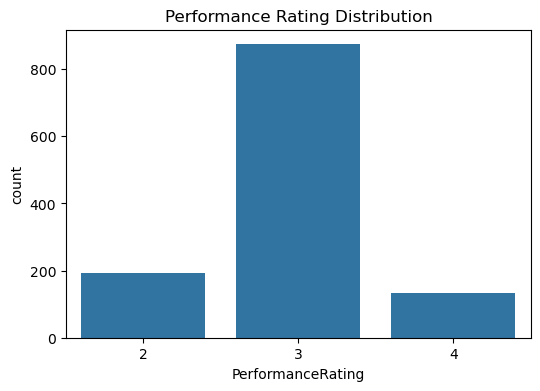

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='PerformanceRating',
    data=df
)

plt.title("Performance Rating Distribution")

plt.show()

# Summary

The employee performance dataset was successfully loaded and explored. Business requirements and project objectives were understood, and the dataset structure, features and target variable were analyzed. Initial exploration confirmed that the dataset contains relevant employee information required for performance analysis and predictive modeling.

# Data Quality Assessment

Before performing detailed analysis and model development, it is important to evaluate the quality of the dataset. This step focuses on identifying missing values, duplicate records and potential outliers that may affect the accuracy of analysis and machine learning models.

In [7]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [8]:
missing_values = pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Percentage": (df.isnull().sum()/len(df))*100
    }
)

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
EmpNumber,0,0.0
Age,0,0.0
Gender,0,0.0
EducationBackground,0,0.0
MaritalStatus,0,0.0
EmpDepartment,0,0.0
EmpJobRole,0,0.0
BusinessTravelFrequency,0,0.0
DistanceFromHome,0,0.0
EmpEducationLevel,0,0.0


## Missing Value Analysis

The dataset was examined for missing values across all features. No missing values were found in any column, indicating that the dataset is complete and does not require missing value treatment. This improves data quality and allows further analysis to proceed without imputation techniques.

In [9]:
df.duplicated().sum()

np.int64(0)

## Duplicate Record Analysis

The dataset was checked for duplicate records to ensure data consistency and reliability. No duplicate records were found in the dataset. This indicates that each employee record is unique and no duplicate removal was required during preprocessing.

In [10]:
df.nunique().sort_values()

Gender                             2
OverTime                           2
Attrition                          2
MaritalStatus                      3
BusinessTravelFrequency            3
PerformanceRating                  3
EmpJobInvolvement                  4
EmpEnvironmentSatisfaction         4
EmpRelationshipSatisfaction        4
EmpJobSatisfaction                 4
EmpWorkLifeBalance                 4
EmpEducationLevel                  5
EmpJobLevel                        5
EducationBackground                6
EmpDepartment                      6
TrainingTimesLastYear              7
NumCompaniesWorked                10
EmpLastSalaryHikePercent          15
YearsSinceLastPromotion           16
YearsWithCurrManager              18
EmpJobRole                        19
ExperienceYearsInCurrentRole      19
DistanceFromHome                  29
ExperienceYearsAtThisCompany      37
TotalWorkExperienceInYears        40
Age                               43
EmpHourlyRate                     71
E

## Unique Value Analysis

The unique value count of each feature was analyzed to understand the dataset structure. Several variables such as Gender, Attrition, OverTime and MaritalStatus contain a limited number of categories and will be treated as categorical variables. Features such as Age, TotalWorkExperienceInYears and DistanceFromHome contain a larger number of unique values and will be treated as numerical variables. EmpNumber contains 1200 unique values, indicating that it is an employee identifier rather than a predictive feature.

In [11]:
df.drop('EmpNumber', axis=1, inplace=True)

## Identifier Column Removal

EmpNumber is a unique identifier assigned to each employee. Since it does not contribute to employee performance prediction, it was removed from the dataset before further analysis and model development.

# Summary

The dataset was assessed for missing values, duplicate records and unique value distributions. No missing values or duplicate records were found, indicating good data quality. The unique value analysis helped distinguish categorical and numerical variables. The EmpNumber feature was identified as an employee identifier and removed from the dataset as it does not contribute to performance prediction.

# Exploratory Data Analysis (EDA)

## Department Wise Performance Analysis

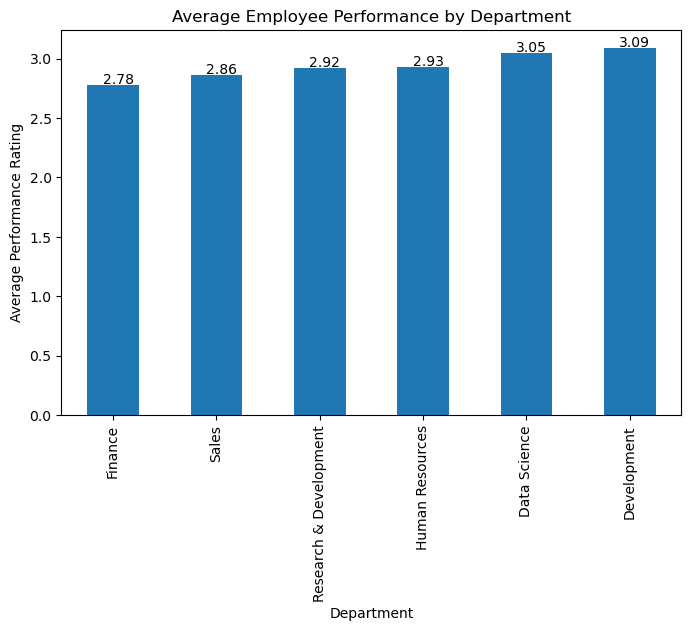

In [13]:
dept_perf = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()

plt.figure(figsize=(8,5))

ax = dept_perf.plot(kind='bar')

plt.title("Average Employee Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Rating")

for i in ax.patches:
    ax.annotate(
        round(i.get_height(),2),
        (i.get_x()+0.15, i.get_height()+0.01)
    )

plt.show()

### Observation

The average employee performance was compared across different departments. The Development department recorded the highest average performance rating, followed closely by Data Science. Finance showed the lowest average performance rating among all departments. Overall, performance ratings across departments are relatively close, indicating a generally consistent performance level throughout the organization, with some departments performing slightly better than others.

### Business Insight

Employees in the Development and Data Science departments demonstrate comparatively stronger performance levels. The Finance department may require additional attention to identify factors affecting employee productivity and performance.

# Job Role vs Performance Rating

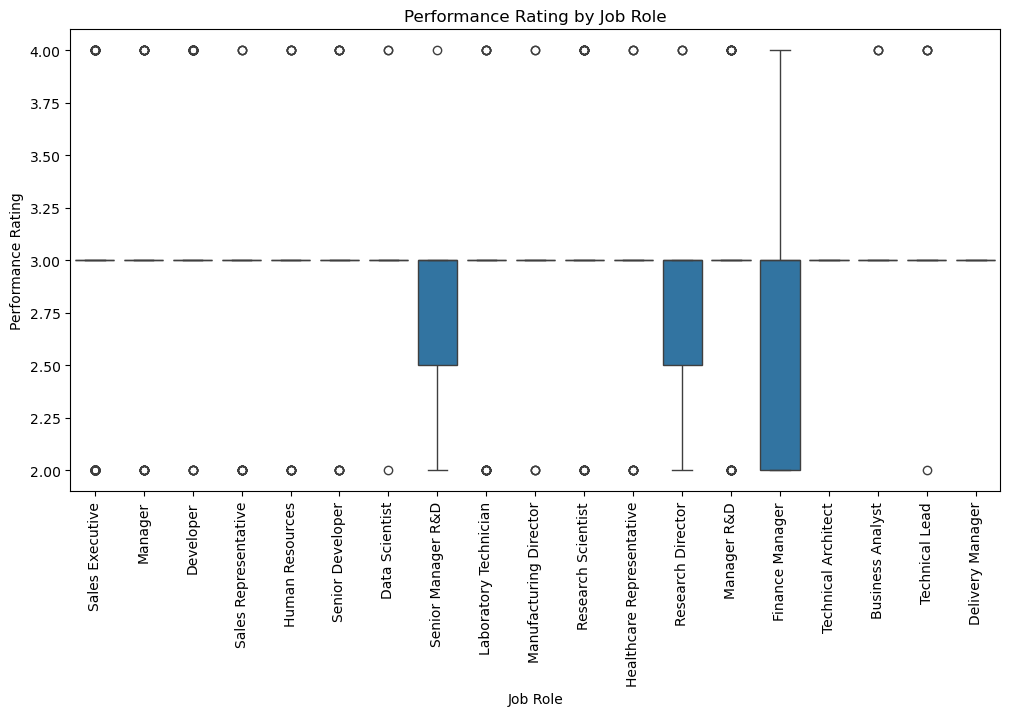

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='EmpJobRole',
    y='PerformanceRating',
    data=df
)

plt.title("Performance Rating by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Performance Rating")

plt.xticks(rotation=90)

plt.show()

### Observation

Employee performance ratings were compared across different job roles. Most job roles show a median performance rating of 3, indicating a generally consistent performance level across the organization. Some variation is observed in a few job roles, but no single role appears to have significantly higher or lower performance compared to others.

### Business Insight

Job role alone does not appear to be a strong differentiating factor for employee performance. Additional factors such as work environment, job satisfaction and work-life balance may have a greater influence on performance outcomes.

## Environment Satisfaction vs Performance Rating

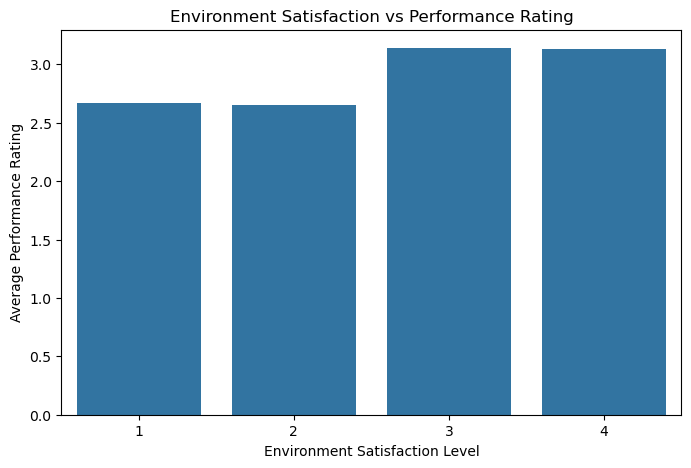

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='EmpEnvironmentSatisfaction',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Environment Satisfaction vs Performance Rating")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

A positive relationship is observed between environment satisfaction and employee performance. Employees with higher environment satisfaction levels (3 and 4) show higher average performance ratings compared to employees with lower satisfaction levels (1 and 2). This indicates that a better work environment contributes positively to employee performance.

### Business Insight

Work environment appears to be an important factor influencing employee performance. Improving workplace conditions, employee engagement and organizational culture may help increase overall employee productivity and performance levels.

## Job Satisfaction vs Performance Rating

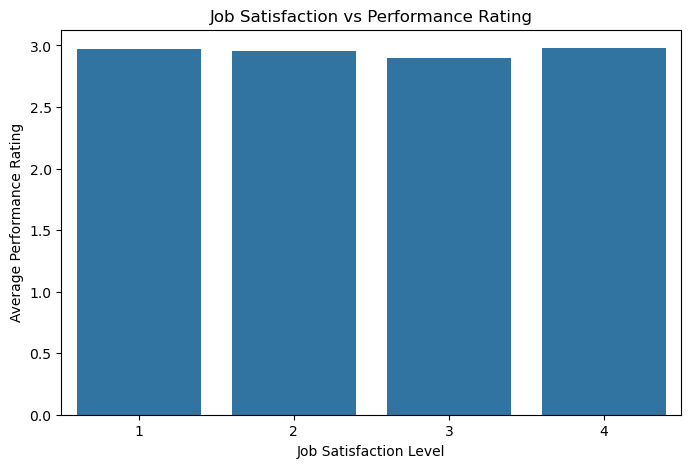

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='EmpJobSatisfaction',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Job Satisfaction vs Performance Rating")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

Job satisfaction does not show a strong impact on employee performance. The average performance ratings remain almost similar across all job satisfaction levels. Only minor variations are observed, indicating that job satisfaction alone may not be a major factor affecting employee performance in this dataset.

### Business Insight

Although job satisfaction is important for employee well-being, it does not appear to significantly influence performance ratings in this analysis. Other factors such as work environment, work-life balance or salary-related factors may have a stronger impact on performance.

## Training Times Last Year vs Performance Rating

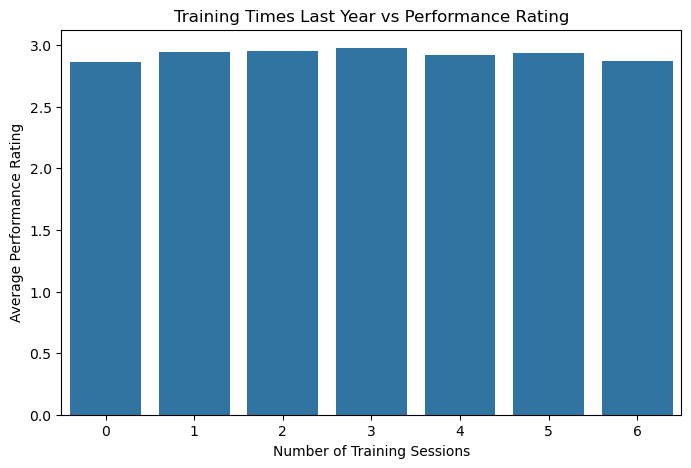

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='TrainingTimesLastYear',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Training Times Last Year vs Performance Rating")
plt.xlabel("Number of Training Sessions")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

Employee performance shows a slight improvement as the number of training sessions increases from 0 to 3. The highest average performance rating is observed among employees who attended 3 training sessions in the previous year. After 3 training sessions, the performance remains relatively stable, indicating that training contributes positively to employee performance but with diminishing returns.

### Business Insight

Training programs appear to have a positive influence on employee performance. Organizations should encourage regular employee training and skill development initiatives. However, increasing training sessions beyond a certain level may not lead to significant additional performance improvements.

## Years Since Last Promotion vs Performance Rating

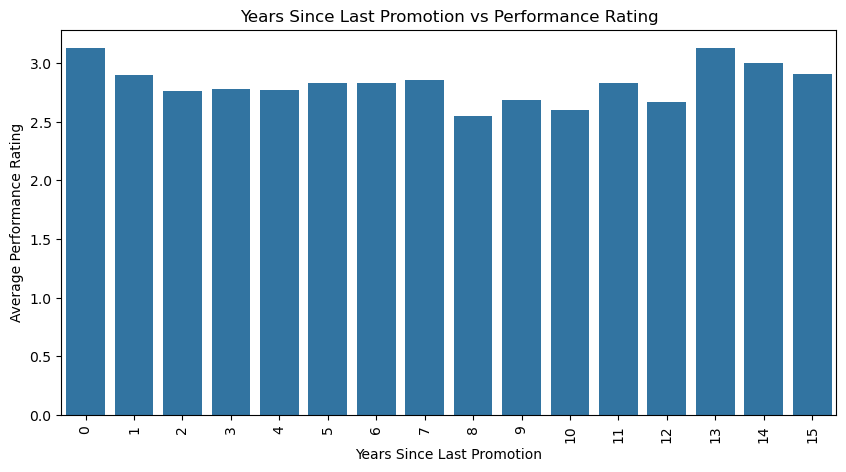

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='YearsSinceLastPromotion',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Years Since Last Promotion vs Performance Rating")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Average Performance Rating")

plt.xticks(rotation=90)

plt.show()

### Observation

The relationship between years since last promotion and employee performance is not strongly linear. Employees with recent promotions and employees with longer promotion gaps both show similar performance levels. Although some fluctuations are observed across different promotion intervals, no consistent decline in performance is visible as promotion years increase.

### Business Insight

Years since last promotion does not appear to be a major standalone factor affecting employee performance. Employee performance may be influenced more by workplace environment, training opportunities and departmental factors than promotion timing alone.

## Work Life Balance vs Performance Rating

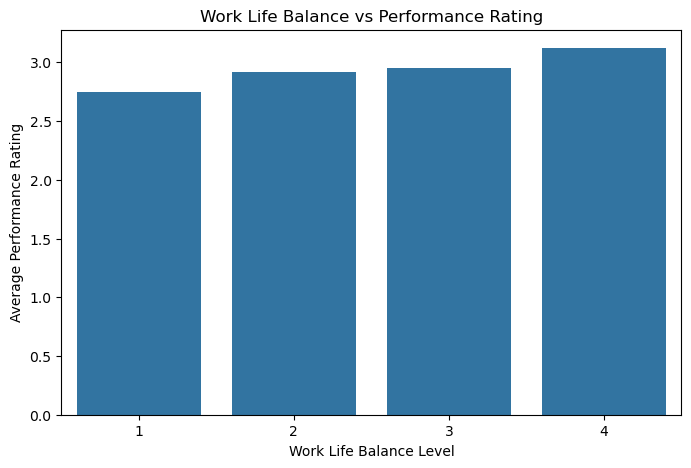

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='EmpWorkLifeBalance',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Work Life Balance vs Performance Rating")
plt.xlabel("Work Life Balance Level")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

A clear positive relationship is observed between work-life balance and employee performance. Employees with higher work-life balance levels show higher average performance ratings. The highest performance is observed among employees with Work Life Balance Level 4, while employees with Level 1 exhibit the lowest average performance. This indicates that maintaining a healthy work-life balance contributes positively to employee productivity and performance.

### Business Insight

Work-life balance is one of the key factors influencing employee performance. Organizations should promote flexible work practices, employee wellness programs and workload management strategies to improve employee performance and job effectiveness.

## Overtime vs Performance Rating

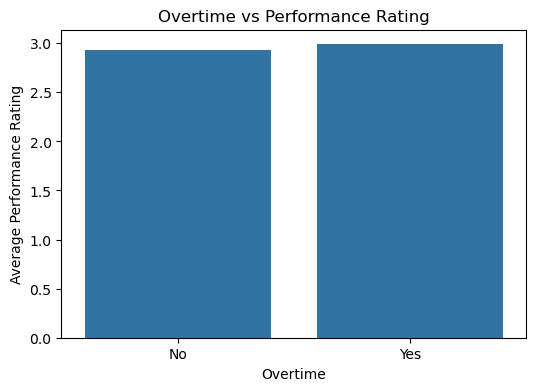

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='OverTime',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Overtime vs Performance Rating")
plt.xlabel("Overtime")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

The average performance ratings of employees working overtime and those not working overtime are almost identical. Only a very small difference is observed between the two groups. This indicates that overtime does not have a significant impact on employee performance in the current dataset.

### Business Insight

Overtime alone does not appear to be a strong driver of employee performance. Employee productivity may be influenced more by factors such as work environment, work-life balance and employee satisfaction rather than additional working hours.

## Salary Hike Percentage vs Performance Rating

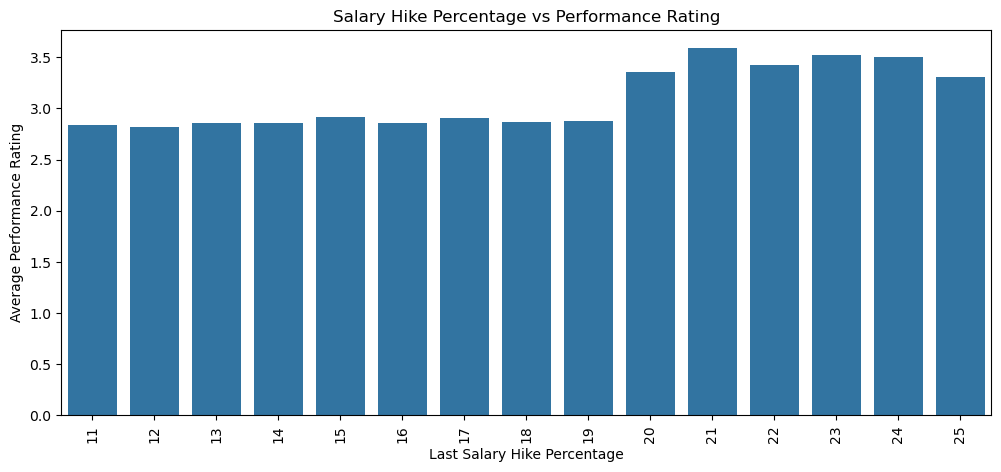

In [21]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='EmpLastSalaryHikePercent',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Salary Hike Percentage vs Performance Rating")
plt.xlabel("Last Salary Hike Percentage")
plt.ylabel("Average Performance Rating")

plt.xticks(rotation=90)

plt.show()

### Observation

A strong positive relationship is observed between salary hike percentage and employee performance. Employees who received salary hikes between 20% and 25% show significantly higher average performance ratings compared to employees receiving hikes between 11% and 19%. The highest average performance is observed around the 21% salary hike level, indicating that higher-performing employees are generally associated with larger salary increments.

### Business Insight

Salary hike percentage appears to be one of the strongest factors associated with employee performance. Performance-based compensation and reward systems can motivate employees and contribute to higher productivity levels. Organizations should ensure that salary increments are aligned with employee performance and achievements.

## Job Involvement vs Performance Rating

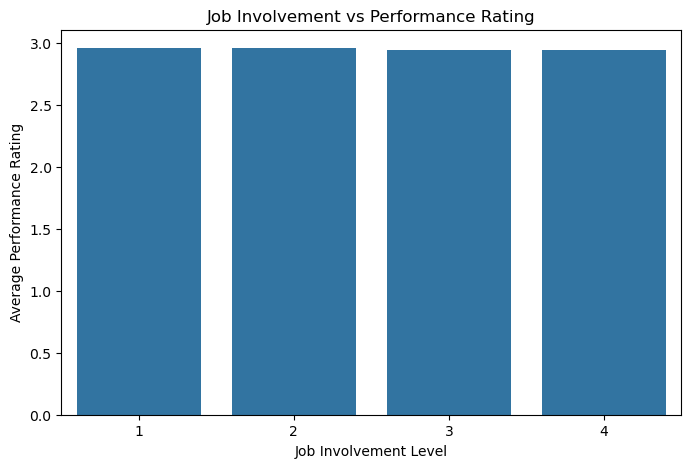

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='EmpJobInvolvement',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Job Involvement vs Performance Rating")
plt.xlabel("Job Involvement Level")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

Job involvement does not show a significant impact on employee performance. The average performance ratings remain almost identical across all job involvement levels. Only minor variations are observed, suggesting that job involvement alone is not a strong predictor of employee performance in this dataset.

### Business Insight

Although employee involvement is important for engagement and organizational commitment, it does not appear to strongly influence performance ratings. Other factors such as salary hike percentage, work-life balance and environment satisfaction have a greater impact on employee performance.

## Relationship Satisfaction vs Performance Rating

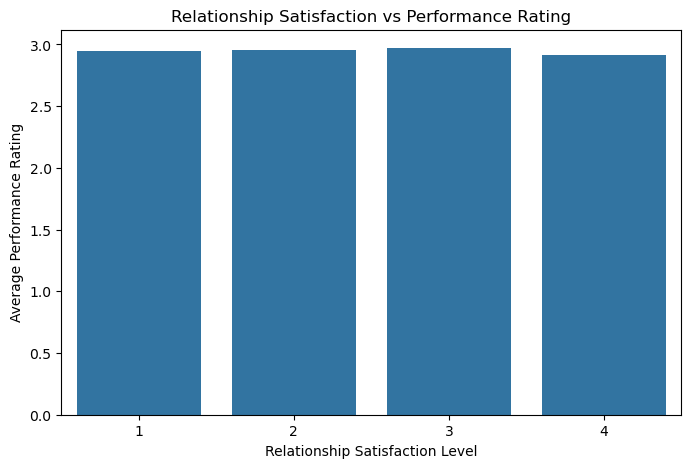

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='EmpRelationshipSatisfaction',
    y='PerformanceRating',
    data=df,
    ci=None
)

plt.title("Relationship Satisfaction vs Performance Rating")
plt.xlabel("Relationship Satisfaction Level")
plt.ylabel("Average Performance Rating")

plt.show()

### Observation

Relationship satisfaction shows very little variation in average performance ratings across different satisfaction levels. Employees with higher relationship satisfaction do not demonstrate significantly different performance levels compared to other groups. This suggests that relationship satisfaction has a limited influence on employee performance in the dataset.

### Business Insight

Relationship satisfaction contributes to employee well-being and workplace harmony, but it does not appear to be a major driver of employee performance. Other organizational factors such as salary growth, work-life balance and environment satisfaction have a stronger association with performance outcomes.

# Summary

Exploratory Data Analysis was conducted to identify factors affecting employee performance. The analysis revealed that Salary Hike Percentage, Environment Satisfaction and Work Life Balance have the strongest positive relationship with employee performance. Training frequency and department also show moderate influence, while factors such as overtime, job satisfaction, relationship satisfaction and job involvement have relatively limited impact on performance ratings.

# Correlation Analysis and Feature Engineering

Before building machine learning models, categorical variables must be converted into numerical format. Correlation analysis helps identify relationships between features and employee performance. This step prepares the dataset for predictive modeling and feature importance analysis.

In [24]:
df.select_dtypes(include='object').columns

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')

### Observation

The dataset contains several categorical features including Gender, EducationBackground, MaritalStatus, EmpDepartment, EmpJobRole, BusinessTravelFrequency, OverTime and Attrition. These variables represent employee characteristics and organizational attributes. Since machine learning algorithms require numerical inputs, these categorical features will be converted into numerical format using Label Encoding.

## Label Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10,2,2,10,7,0,8,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20,2,3,7,7,1,7,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20,2,3,18,13,1,12,0,4
3,41,1,0,0,3,8,2,10,4,2,...,2,23,2,2,21,6,12,6,0,3
4,60,1,2,2,5,13,2,16,4,1,...,4,10,1,3,2,2,2,2,0,3


### Observation

Label Encoding was successfully applied to all categorical variables in the dataset. Features such as Gender, Department, Job Role, Marital Status and Business Travel Frequency were converted into numerical representations. This transformation enables machine learning algorithms to process the data efficiently while maintaining the information contained in categorical attributes.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           1200 non-null   int64
 1   Gender                        1200 non-null   int64
 2   EducationBackground           1200 non-null   int64
 3   MaritalStatus                 1200 non-null   int64
 4   EmpDepartment                 1200 non-null   int64
 5   EmpJobRole                    1200 non-null   int64
 6   BusinessTravelFrequency       1200 non-null   int64
 7   DistanceFromHome              1200 non-null   int64
 8   EmpEducationLevel             1200 non-null   int64
 9   EmpEnvironmentSatisfaction    1200 non-null   int64
 10  EmpHourlyRate                 1200 non-null   int64
 11  EmpJobInvolvement             1200 non-null   int64
 12  EmpJobLevel                   1200 non-null   int64
 13  EmpJobSatisfaction            120

### Observation

The dataset was verified after encoding and all features were successfully converted into numerical format. Each column contains 1200 non-null values, indicating that no missing values are present. Since all features are now represented as integer values, the dataset is fully prepared for correlation analysis and machine learning model development.

## Correlation with Performance Rating

In [27]:
performance_corr = df.corr()['PerformanceRating']

performance_corr.sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
OverTime                        0.050206
MaritalStatus                   0.024172
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EducationBackground             0.005607
EmpJobSatisfaction              0.000606
Gender                         -0.001780
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
BusinessTravelFrequency        -0.031025
Attrition                      -0.039796
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
EmpJobRole                     -0.096209
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsI

### Observation

Correlation analysis was performed to identify the relationship between employee performance and other features. Employee Environment Satisfaction shows the highest positive correlation with Performance Rating (0.396), followed by Last Salary Hike Percentage (0.334) and Work Life Balance (0.124). These features demonstrate the strongest positive influence on employee performance and are likely to be important predictors in machine learning models.

### Business Insight

Employee performance is strongly influenced by workplace environment, salary growth and work-life balance. Employees who are satisfied with their work environment and receive better salary increments tend to demonstrate higher performance levels. Organizations should focus on improving employee experience, reward systems and work-life balance initiatives to enhance overall productivity.

#  Summary

Categorical variables were successfully encoded using Label Encoding and the dataset was prepared for machine learning. Correlation analysis revealed that Environment Satisfaction, Last Salary Hike Percentage and Work Life Balance are the most influential factors affecting employee performance. These findings will guide feature selection and model development in the next stage of the project.

## Feature Selection

In [28]:
X = df.drop('PerformanceRating', axis=1)

y = df['PerformanceRating']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1200, 26)
Target Shape : (1200,)


### Observation

The dataset was separated into independent variables and the target variable. A total of 26 features were selected as input variables, while Performance Rating was chosen as the prediction target. This dataset structure is suitable for classification model development.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (960, 26)
Testing Shape : (240, 26)


### Observation

The dataset was divided into training and testing subsets using an 80:20 ratio. The training set contains 960 employee records and is used for model learning, while the testing set contains 240 records and is used to evaluate model performance on unseen data.

## Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8458333333333333


### Observation

The Logistic Regression model achieved an accuracy of 84.58% on the test dataset. This indicates that the model is capable of predicting employee performance with good accuracy and serves as a strong baseline for comparison with more advanced machine learning algorithms.

## Decision Tree Classifier

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.8875


### Observation

The Decision Tree model achieved an accuracy of 88.75%, outperforming Logistic Regression. The model successfully captured complex relationships between employee attributes and performance ratings, resulting in improved prediction accuracy.

## Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9458333333333333


In [33]:
accuracy_df = pd.DataFrame(
    {
        'Model': [
            'Logistic Regression',
            'Decision Tree',
            'Random Forest'
        ],
        'Accuracy': [
            0.8458,
            0.8875,
            0.9458
        ]
    }
)

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.8458
1,Decision Tree,0.8875
2,Random Forest,0.9458


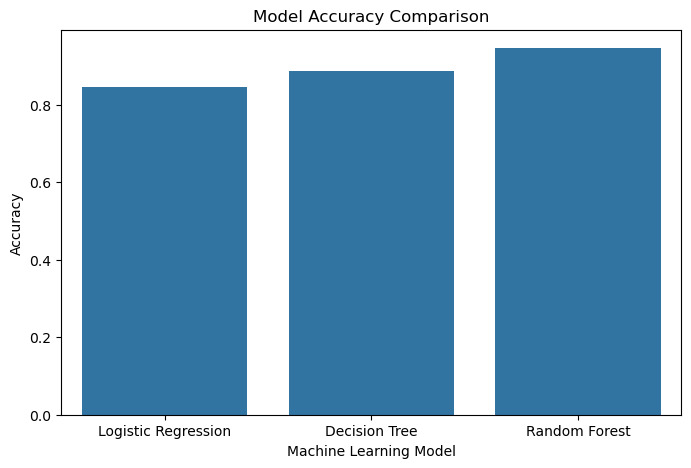

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.show()

### Observation

Three machine learning algorithms were evaluated for employee performance prediction. Random Forest achieved the highest accuracy of 94.58%, followed by Decision Tree with 88.75% and Logistic Regression with 84.58%. The Random Forest model demonstrated superior predictive capability and was selected as the final model for this project.

## Best Model Selection

Among all evaluated models, Random Forest achieved the highest prediction accuracy of 94.58%. Due to its strong predictive performance and ability to handle complex feature interactions, Random Forest was selected as the final model for employee performance prediction.

## Feature Importance Analysis

In [35]:
feature_importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,EmpEnvironmentSatisfaction,0.219013
16,EmpLastSalaryHikePercent,0.212347
23,YearsSinceLastPromotion,0.090565
22,ExperienceYearsInCurrentRole,0.043961
4,EmpDepartment,0.039529
5,EmpJobRole,0.037145
10,EmpHourlyRate,0.035377
0,Age,0.032529
21,ExperienceYearsAtThisCompany,0.031829
7,DistanceFromHome,0.027037


### Observation

Feature Importance analysis was performed using the Random Forest model. Employee Environment Satisfaction emerged as the most influential feature, followed closely by Last Salary Hike Percentage. Years Since Last Promotion was identified as the third most important factor affecting employee performance. These features contribute significantly to the predictive capability of the model and provide valuable business insights.

## Top 3 Factors Affecting Employee Performance

1. Employee Environment Satisfaction
2. Last Salary Hike Percentage
3. Years Since Last Promotion

These factors were identified using Random Forest Feature Importance Analysis and demonstrated the strongest influence on employee performance ratings.

### Business Insight

Employees working in a positive work environment tend to achieve higher performance ratings. Salary growth also plays a crucial role in motivating employees and improving productivity. Promotion-related factors influence employee engagement and long-term performance, highlighting the importance of career growth opportunities within the organization.

# Model Development Summary

Three machine learning algorithms were evaluated for employee performance prediction. Logistic Regression achieved an accuracy of 84.58%, Decision Tree achieved 88.75% and Random Forest achieved 94.58%. Random Forest was selected as the final model due to its superior performance. Feature Importance analysis revealed that Environment Satisfaction, Salary Hike Percentage and Years Since Last Promotion are the most influential factors affecting employee performance.

# Business Insights

### Key Business Insights

The analysis revealed that Employee Environment Satisfaction is the most important factor influencing employee performance. Employees who are satisfied with their workplace environment tend to achieve higher performance ratings.

Salary Hike Percentage was identified as the second most influential factor. Employees receiving higher salary increments generally demonstrated better performance levels.

Years Since Last Promotion also showed a significant impact on employee performance, indicating that career growth opportunities play an important role in maintaining employee motivation and productivity.

Departments such as Development and Data Science showed comparatively higher performance ratings, while some departments displayed lower average performance levels and may require additional managerial attention.

# Recommendations

### Recommendations

1. Improve workplace environment by promoting employee engagement, collaboration and positive organizational culture.

2. Implement performance-based reward and salary increment programs to motivate employees and encourage higher productivity.

3. Provide clear promotion and career development opportunities to maintain employee motivation and long-term commitment.

4. Continue investing in employee training and skill development programs to enhance professional growth.

5. Monitor department-level performance regularly and provide targeted support to departments with lower performance ratings.

6. Promote work-life balance initiatives to improve employee satisfaction and overall organizational performance.

# Project Questions and Answers

### Question 1
Which department has the highest employee performance?

Answer:
The Development department demonstrated the highest average employee performance rating, followed closely by the Data Science department.

### Question 2
What are the top 3 factors affecting employee performance?

Answer:
1. Employee Environment Satisfaction
2. Last Salary Hike Percentage
3. Years Since Last Promotion

These factors were identified using Random Forest Feature Importance Analysis.

### Question 3
Can employee performance be predicted using machine learning?

Answer:
Yes. Multiple machine learning models were developed and evaluated. Random Forest achieved the highest prediction accuracy of 94.58%, making it the best-performing model.

### Question 4
What actions can improve employee performance?

Answer:
Improving workplace environment, providing competitive salary increments, offering promotion opportunities and supporting work-life balance can significantly improve employee performance.

# Project Conclusion

### Conclusion

This project successfully analyzed employee performance data and identified the major factors influencing employee performance within INX Future Inc. Exploratory Data Analysis, Correlation Analysis and Machine Learning techniques were applied to understand employee behavior and performance patterns.

The analysis revealed that Environment Satisfaction, Salary Hike Percentage and Years Since Last Promotion are the most important factors affecting employee performance. Among the evaluated machine learning models, Random Forest achieved the highest accuracy of 94.58% and was selected as the final predictive model.

The findings of this project can support management in making data-driven decisions related to employee engagement, compensation strategies and career development programs, ultimately leading to improved organizational performance.

# Final Project Summary

The Employee Performance Analysis project was completed using a structured data science approach including data understanding, data cleaning, exploratory data analysis, feature engineering and machine learning model development.

The dataset contained 1200 employee records and 27 features. No missing values or duplicate records were found. Feature Importance Analysis identified Environment Satisfaction, Salary Hike Percentage and Years Since Last Promotion as the most influential factors affecting employee performance.

Three machine learning models were developed and evaluated. Random Forest achieved the highest accuracy of 94.58% and was selected as the final model. The project successfully answered all business questions and provided actionable recommendations to improve employee performance and organizational productivity.